# Customer Retention

In [2]:
import importlib
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# --- Display formatting (readable numbers in notebook output) ---
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# --- Notebook output controls (clean vs verbose mode) ---
SHOW_VERBOSE_TABLES = False
PREVIEW_ROWS = 10

def show_df(df, title=None, n=PREVIEW_ROWS):
    """Display full table only in verbose mode; otherwise show top-N preview."""
    if title:
        print(title)
    display(df if SHOW_VERBOSE_TABLES else df.head(n))

# --- Configuration ---
# set USE_SAMPLE = True for quick testing, False for full dataset analysis
USE_SAMPLE = False

# Setup project path
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists() and (parent / "data").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Reload the loader module so notebook execution always uses the latest code.
import instacart_quality.data_access as data_access_module
importlib.reload(data_access_module)

df = data_access_module.load_customer_behavior_data(
    use_sample=USE_SAMPLE,
    project_root=PROJECT_ROOT,
)

print(f"Loaded {len(df):,} records with {df['user_id'].nunique():,} unique customers")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"Data mode: {'SAMPLE' if USE_SAMPLE else 'FULL DATASET'}")
print(f"Columns: {list(df.columns)}\n")

df.head()

Loaded 32,434,489 records with 206,209 unique customers
Date range: 2014-07-01 to 2015-07-01
Data mode: FULL DATASET
Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'cumulative_days', 'order_date', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department', 'total_price', 'cumulative_reorder_per_customer']



,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,cumulative_days,order_date,product_name,aisle_id,department_id,aisle,department,total_price,cumulative_reorder_per_customer
0,2539329,196,1,0,1,prior,1,2,8,0.0,0.0,2014-12-23,Soda,77,7,soft drinks,beverages,1,0
1,2539329,14084,2,0,1,prior,1,2,8,0.0,0.0,2014-12-23,Organic Unsweetened Vanilla Almond Milk,91,16,soy lactosefree,dairy eggs,1,0
2,2539329,12427,3,0,1,prior,1,2,8,0.0,0.0,2014-12-23,Original Beef Jerky,23,19,popcorn jerky,snacks,1,0
3,2539329,26088,4,0,1,prior,1,2,8,0.0,0.0,2014-12-23,Aged White Cheddar Popcorn,23,19,popcorn jerky,snacks,1,0
4,2539329,26405,5,0,1,prior,1,2,8,0.0,0.0,2014-12-23,XL Pick-A-Size Paper Towel Rolls,54,17,paper goods,household,1,0


In [3]:
df["order_date"].min(), df["order_date"].max()

(Timestamp('2014-07-01 00:00:00'), Timestamp('2015-07-01 00:00:00'))

In [4]:
# Sanity check: order_date should move forward with order_number for a sample user
(
    df[["user_id", "order_number", "days_since_prior_order", "order_date"]]
    .drop_duplicates()
    .query("user_id == 1")
    .sort_values("order_number")
)

,user_id,order_number,days_since_prior_order,order_date
0,1,1,0.0,2014-12-23
5,1,2,15.0,2015-01-07
11,1,3,21.0,2015-01-28
16,1,4,29.0,2015-02-26
21,1,5,28.0,2015-03-26
29,1,6,19.0,2015-04-14
33,1,7,20.0,2015-05-04
38,1,8,14.0,2015-05-18
44,1,9,0.0,2015-05-18
50,1,10,30.0,2015-06-17


In [5]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

# 1) Order frequency + reorder behavior + recency per user
user_order_profile = (
    df.groupby("user_id", observed=False)
    .agg(
        total_orders=("order_id", "nunique"),
        reorder_ratio=("reordered", "mean"),
        last_order_date=("order_date", "max"),
    )
    .reset_index()
)

# 2) Basket size per order -> average basket size at user level
order_basket = (
    df.groupby(["user_id", "order_id"], observed=False)
    .agg(basket_size=("product_id", "count"))
    .reset_index()
)

user_basket_profile = (
    order_basket.groupby("user_id", observed=False)
    .agg(avg_basket_size=("basket_size", "mean"))
    .reset_index()
)

# Keep variable name `rfm` for downstream compatibility in this notebook.
rfm = user_order_profile.merge(user_basket_profile, on="user_id", how="left")
rfm["days_since_last_order"] = (snapshot_date - rfm["last_order_date"]).dt.days

## 1. Order-Based Retention OR "Repeat Purchase Behavior"

เป้าหมาย: ดูว่า “วัดว่าลูกค้าสั่งซื้อซ้ำต่อเนื่องไปจนถึงครั้งที่เท่าไหร่”

สาเหตุ: เนื่องจาก ข้อมูลไม่มี เวลา ของผู้ไช้งาน เราจึงจําลลองวันจาก Reorder ด้วยมุมมอง การที่ลูกค้ากลับมาซื้อครั้งที่ 2, 3, 4... ก็คือการที่เขา "Retained" (ยังไม่เลิกใช้) นั่นเอง

In [19]:
# Build a clean cohort table without mutating the original df
cohort_df = df.copy()

cohort_df["order_date"] = pd.to_datetime(cohort_df["order_date"])
cohort_df["order_month"] = cohort_df["order_date"].dt.to_period("M")

# ❗ สำคัญ: กัน user ซ้ำในเดือนเดียว
cohort_df = cohort_df.drop_duplicates(["user_id", "order_month"])

cohort = (
    cohort_df.groupby("user_id")["order_month"]
    .min()
    .reset_index(name="cohort_month")
)

cohort_df = cohort_df.merge(cohort, on="user_id")

# ---------------------------
# 3. Create cohort index
# ---------------------------
cohort_df["cohort_index"] = (
    (cohort_df["order_month"].dt.year - cohort_df["cohort_month"].dt.year) * 12
    + (cohort_df["order_month"].dt.month - cohort_df["cohort_month"].dt.month)
)

# ---------------------------
# 4. Build cohort table
# ---------------------------
cohort_table = (
    cohort_df.groupby(["cohort_month", "cohort_index"])["user_id"]
    .nunique()
    .unstack()  # ❗ ไม่ใช้ fill_value=0
)

# ---------------------------
# 5. Retention
# ---------------------------
cohort_size = cohort_table.iloc[:, 0]
retention = cohort_table.divide(cohort_size, axis=0)

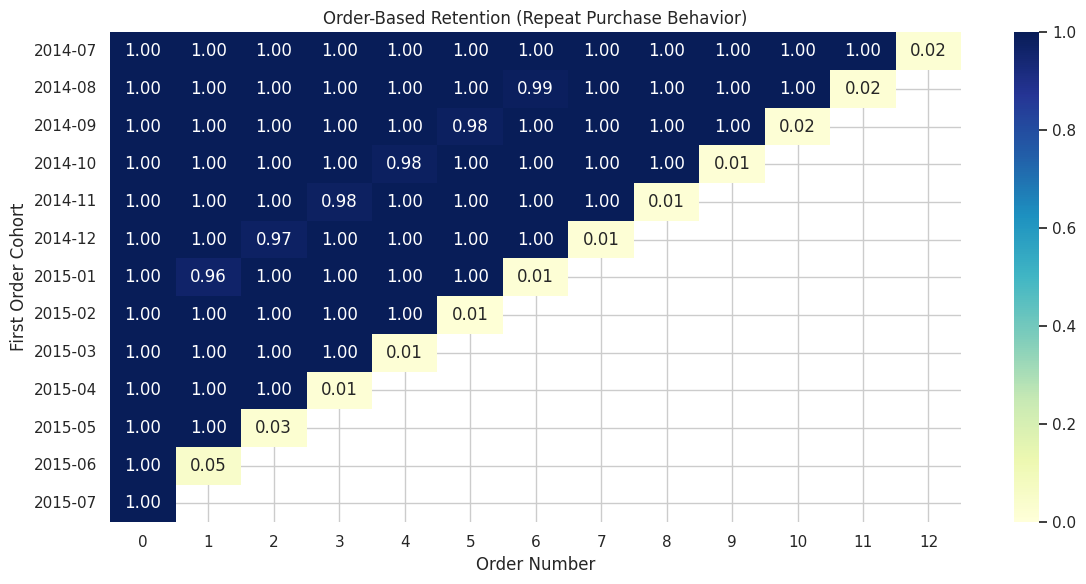

In [21]:
# 6. Plot
# ---------------------------
plt.figure(figsize=(12, 6))
sns.heatmap(
    retention,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1
)

plt.title("Order-Based Retention (Repeat Purchase Behavior)")
plt.xlabel("Order Number")
plt.ylabel("First Order Cohort")
plt.tight_layout()
plt.show()

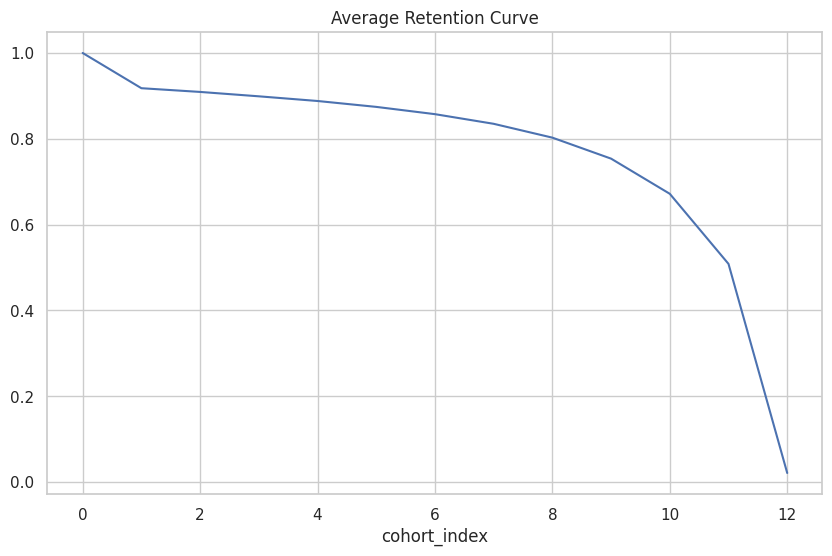

In [22]:
plt.figure(figsize=(10,6))
retention.mean().plot()
plt.title("Average Retention Curve")
plt.show()

หัวข้อ: Repeat Purchase Behavior Analysis (Order-Based Retention)

คำอธิบาย (Insight): * "จากการวิเคราะห์พฤติกรรมการสั่งซื้อซ้ำ พบว่าลูกค้าในทุก Cohort มีค่า Retention ในเชิงจำนวนครั้ง (Order Number) สูงมาก"

    "จุดที่ค่าตกลง (Diagonal Line) สะท้อนถึงขีดจำกัดของเวลาในชุดข้อมูล มากกว่าจะเป็นการ Churn จริงของลูกค้า"

ข้อจำกัด (Disclaimer): * "เนื่องจากวันที่สั่งซื้อ (Order Date) ถูกประมาณการย้อนหลัง ข้อมูลนี้จึงมุ่งเน้นไปที่การวิเคราะห์ความต่อเนื่องของพฤติกรรม (Behavioral Continuity) มากกว่าการวัดอัตราการรักษาสมาชิกตามเวลาจริง (Real-time Survival Rate)"

## retention by Whale vs Regular

In [23]:
# Create Whale vs Regular segments from the existing user-level profile
whale_threshold = rfm["total_orders"].quantile(0.90)
segment_map = rfm[["user_id", "total_orders"]].copy()
segment_map["segment"] = "Regulars"
segment_map.loc[segment_map["total_orders"] >= whale_threshold, "segment"] = "Whales"

cohort_df_seg = cohort_df.merge(segment_map[["user_id", "segment"]], on="user_id", how="left")

cohort_table_seg = (
    cohort_df_seg
    .groupby(["segment", "cohort_month", "cohort_index"], observed=False)["user_id"]
    .nunique()
    .reset_index()
)

pivot_seg = cohort_table_seg.pivot_table(
    index=["segment", "cohort_month"],
    columns="cohort_index",
    values="user_id",
    fill_value=0
)

# FIX 1: make columns continuous
full_range = range(
    pivot_seg.columns.min(),
    pivot_seg.columns.max() + 1
)
pivot_seg = pivot_seg.reindex(columns=full_range)

# FIX 2: retention
retention_seg = pivot_seg.divide(
    pivot_seg.iloc[:, 0].replace(0, np.nan),
    axis=0
)

# FIX 3: sort
retention_seg = retention_seg.sort_index().sort_index(axis=1)

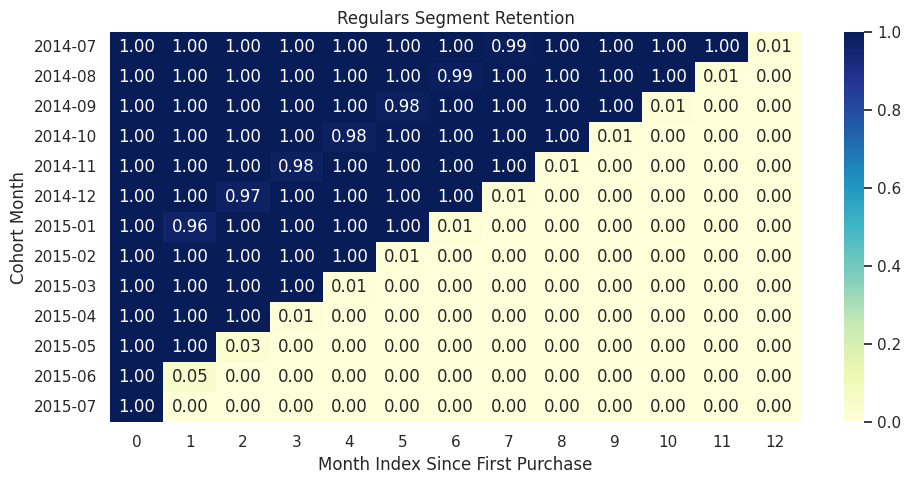

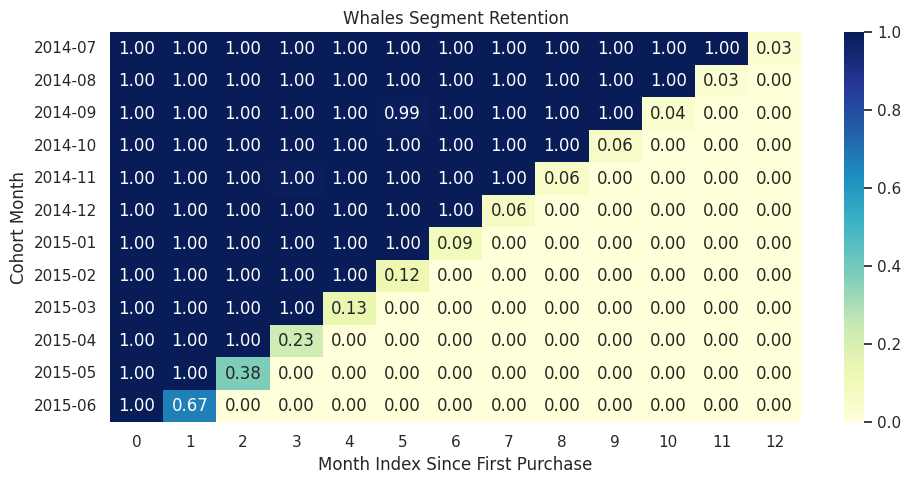

In [24]:
segments = list(retention_seg.index.get_level_values(0).unique())

# บังคับลำดับ: Regular มาก่อน
segments = sorted(segments, key=lambda x: 0 if x == "Regulars" else 1)

for seg in segments:
    seg_data = retention_seg.loc[seg].copy()

    # 🔧 กันพัง: sort + fill
    seg_data = seg_data.sort_index().sort_index(axis=1)
    seg_data = seg_data.fillna(0)

    # 🔥 สร้าง figure ใหม่ทุกครั้ง
    plt.figure(figsize=(10, 5))

    sns.heatmap(
        seg_data,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        vmin=0,
        vmax=1,
        mask=seg_data.isna(),  # ใช้ mask ของตัวเอง
        cbar=True
    )

    plt.title(f"{seg} Segment Retention")
    plt.xlabel("Month Index Since First Purchase")
    plt.ylabel("Cohort Month")

    plt.tight_layout()
    plt.show()

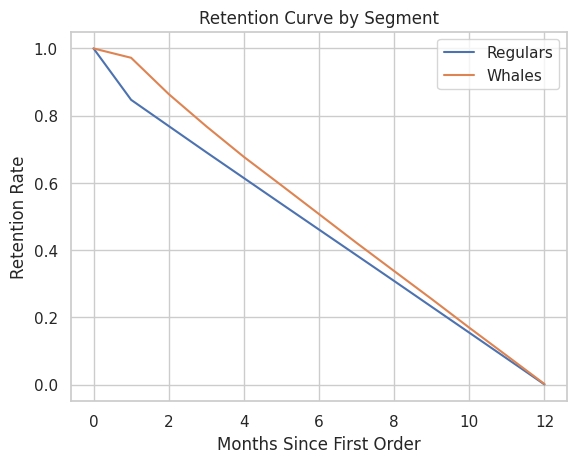

: 

In [ ]:
for seg in retention_seg.index.get_level_values(0).unique():
    data = retention_seg.loc[seg]
    avg_retention = data.mean()

    plt.plot(avg_retention.index, avg_retention.values, label=seg)

plt.legend()
plt.title("Retention Curve by Segment")
plt.xlabel("Months Since First Order")
plt.ylabel("Retention Rate")
plt.show()

In [13]:
mean_retention = retention.mean()

print("Mean Retention Rates:")
print(mean_retention.to_string())


Mean Retention Rates:
cohort_index
0     1.000000
1     0.847231
2     0.769385
3     0.691538
4     0.614846
5     0.538077
6     0.461692
7     0.385385
8     0.308692
9     0.231923
10    0.155000
11    0.078231
12    0.001615


In [14]:
median_retention = retention.median()

print("\nMedian Retention Rates:")
print(median_retention.to_string())


Median Retention Rates:
cohort_index
0     1.000
1     1.000
2     1.000
3     1.000
4     1.000
5     0.983
6     0.014
7     0.000
8     0.000
9     0.000
10    0.000
11    0.000
12    0.000


## 2. Early Warning Signal

เป้าหมาย: “ทำนายว่าใครกำลังจะหาย”

In [15]:
df["order_date"] = pd.to_datetime(df["order_date"])
last_order = df.groupby("user_id")["order_date"].max()

snapshot_date = df["order_date"].max()

user_df = last_order.reset_index()

user_df["days_since_last"] = (
    snapshot_date - user_df["order_date"]
).dt.days

In [16]:
user_df["days_since_last"].describe()

count    206209.000000
mean         17.061782
std          10.672178
min           0.000000
25%           7.000000
50%          15.000000
75%          30.000000
max          30.000000
Name: days_since_last, dtype: float64

In [17]:
threshold = user_df["days_since_last"].quantile(0.6)

user_df["churn"] = user_df["days_since_last"] > threshold
user_df.groupby("churn")["days_since_last"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
False,124571.0,9.250419,5.588779,0.0,5.0,8.0,14.0,21.0
True,81638.0,28.981099,2.202295,22.0,30.0,30.0,30.0,30.0


## 3. Churn Prediction

เป้าหมาย: หา pattern ก่อน churn